# Automotive Part Image-Text Matching

**Deep Learning exam project**

I wanted to test one concrete question:

> Can a small neural network that uses both an image and a short text description classify their relationship better than image-only, text-only, and a simple non-neural image-and-text baseline?

The project is a three-class classification problem:

- **MATCH**: the image and text describe the same part category;
- **PARTIAL_MATCH**: the categories are different but belong to the same automotive system;
- **MISMATCH**: the categories belong to different systems.

The result is a course experiment. It is not a production model.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report

ROOT = Path.cwd()
if not (ROOT / "data").is_dir():
    ROOT = ROOT.parent

train = pd.read_csv(ROOT / "data/train.csv")
validation = pd.read_csv(ROOT / "data/validation.csv")
comparison = pd.read_csv(ROOT / "results/model_comparison.csv")
predictions = pd.read_csv(ROOT / "results/multimodal_validation_predictions.csv")
audit = json.loads((ROOT / "results/data_audit.json").read_text(encoding="utf-8"))
run_info = json.loads((ROOT / "results/run_info.json").read_text(encoding="utf-8"))

print(f"Train samples: {len(train)}")
print(f"Validation samples: {len(validation)}")
print(f"Train groups: {train.part_group_id.nunique()}")
print(f"Validation groups: {validation.part_group_id.nunique()}")
print(f"Test split used: {run_info['test_split_used']}")

Train samples: 180
Validation samples: 60
Train groups: 60
Validation groups: 20
Test split used: False


## 1. Data

I used two image sources:

1. simple synthetic drawings used as development data;
2. open-license photographs from Wikimedia Commons.

The drawings are marked as `generated` in the CSV files and are not presented as real photographs. The Wikimedia authors and licenses are recorded in `data/licenses.csv`.

Each physical part appears three times because it is paired with one text for each label. The three rows share the same `part_group_id` and must stay in the same split.

In [2]:
summary = pd.DataFrame({
    "train": [len(train), train.image_id.nunique(), train.part_group_id.nunique()],
    "validation": [len(validation), validation.image_id.nunique(), validation.part_group_id.nunique()],
}, index=["samples", "images", "part groups"])
summary

,train,validation
samples,180,60
images,60,20
part groups,60,20


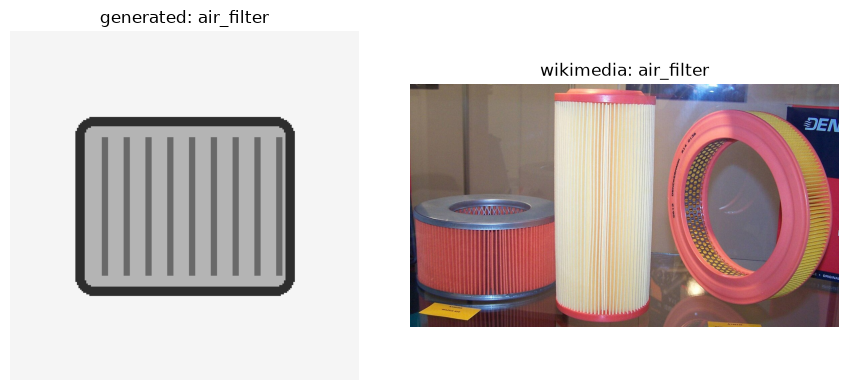

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
examples = [
    train[train.source.eq("generated")].iloc[0],
    train[train.source.eq("wikimedia")].iloc[0],
]
for ax, row in zip(axes, examples):
    with Image.open(ROOT / row.image_path) as image:
        ax.imshow(image.convert("RGB"))
    ax.set_title(f"{row.source}: {row.part_category}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 2. Split and leakage checks

I split by `part_group_id`, not by CSV row. This prevents the same physical part from appearing in both train and validation.

I also checked the image IDs, file paths, exact file hashes, and the locked test-file hash.

In [4]:
overlap_table = pd.DataFrame({
    "check": ["part_group_id", "image_id", "image_path", "exact image hash"],
    "train-validation overlap": [
        audit["overlap"]["group_overlap"],
        audit["overlap"]["image_id_overlap"],
        audit["overlap"]["image_path_overlap"],
        audit["exact_cross_split_image_hash_overlap"],
    ],
})
overlap_table

,check,train-validation overlap
0,part_group_id,0
1,image_id,0
2,image_path,0
3,exact image hash,0


In [5]:
label_balance = pd.crosstab(validation["source"], validation["label"])
label_balance

label,MATCH,MISMATCH,PARTIAL_MATCH
source,,,
generated,10,10,10
wikimedia,10,10,10


### A problem I found

The exact-file checks pass, but some generated drawings are still visually very similar. A simple 32×32 grayscale similarity check found train-validation pairs above 0.99 similarity for the generated source and none for the Wikimedia source.

This does not mean that the real photographs are perfect or that the similarity check is a formal proof. It is a warning that the generated part of the validation score may be optimistic. For this reason, I also report the result on the real-image subset.

In [6]:
pd.DataFrame({
    "source": ["generated", "wikimedia"],
    "visually similar train-validation pairs (similarity >= 0.99)": [
        audit["generated_similar_pairs_at_0_99"],
        audit["wikimedia_similar_pairs_at_0_99"],
    ],
})

,source,visually similar train-validation pairs (similarity >= 0.99)
0,generated,15
1,wikimedia,0


## 3. Shortcut and dataset-design checks

A model should not predict the label only from the image source or the part category. Both metadata-only checks stay at the majority level of 0.333 accuracy.

There are also two important limits in the task design:

- all 14 validation descriptions also occur in training, so the text-only result measures this small fixed vocabulary rather than general language understanding;
- every image is paired once with each relation label, so an image-only model cannot identify the relation without seeing the text. A deterministic image-only classifier can be correct on only one of the three rows for each image, which gives an expected ceiling of 0.333 accuracy.

In [7]:
shortcut = pd.read_csv(ROOT / "results/shortcut_baselines.csv")
print("Metadata shortcut baselines")
display(shortcut)

pd.DataFrame({
    "check": [
        "unique validation descriptions",
        "validation descriptions also seen in train",
        "validation rows with a seen description",
        "image-only relation ceiling",
        "test-lock SHA matches",
    ],
    "value": [
        audit["unique_descriptions_validation"],
        audit["validation_unique_descriptions_seen_in_train"],
        audit["validation_rows_with_seen_description"],
        audit["image_only_relation_ceiling_accuracy"],
        audit["test_lock"]["sha256_matches"],
    ],
})

Metadata shortcut baselines


,features,accuracy,macro_f1
0,source,0.333333,0.166667
1,part_category,0.333333,0.166667
2,source+part_category,0.333333,0.166667
3,description_category,0.416667,0.332265


,check,value
0,unique validation descriptions,14
1,validation descriptions also seen in train,14
2,validation rows with a seen description,60
3,image-only relation ceiling,0.333333
4,test-lock SHA matches,True


## 4. Models

I compared seven models on the same validation rows:

1. majority baseline;
2. TF-IDF with Logistic Regression;
3. flattened image pixels with Logistic Regression;
4. image pixels and TF-IDF joined in one Logistic Regression model;
5. a small text neural network;
6. a small image neural network;
7. a multimodal neural network.

The simple image-and-text Logistic Regression model is important because it checks whether merely combining both inputs is enough. The neural multimodal model should beat this baseline, not only the image-only and text-only models.

The neural multimodal model has two branches. The text branch uses an embedding and average pooling. The image branch uses resized pixels and dense layers. Their features are joined before the final three-class output.

I used small models because the dataset is small. The full training code is in `src/train.py` and the model definitions are in `src/models.py`.

## 5. Metrics

I use accuracy and macro F1.

\[
\text{Accuracy}=\frac{\text{correct predictions}}{\text{all predictions}}
\]

For one class:

\[
F1=2\frac{\text{precision}\cdot\text{recall}}{\text{precision}+\text{recall}}
\]

Macro F1 is the mean of the three class F1 scores. I use it because the three classes are equally important.

## 6. Validation results

The full validation split has 60 pairs. Half use generated images and half use real Wikimedia images.

The Keras multimodal model ranks first on both the full validation split and the real-image subset. It also performs better than the simple non-neural image-and-text baseline. The real-image result is lower and is the more cautious number.

In [8]:
display_table = comparison[[
    "model", "modality", "full_validation_accuracy", "full_validation_macro_f1",
    "real_image_accuracy", "real_image_macro_f1"
]].copy()
for column in display_table.columns[2:]:
    display_table[column] = display_table[column].round(4)
display_table

,model,modality,full_validation_accuracy,full_validation_macro_f1,real_image_accuracy,real_image_macro_f1
0,Keras multimodal model,image + text,0.5000,0.4898,0.3667,0.3556
1,Image + text Logistic Regression,image + text,0.4500,0.4192,0.3333,0.3015
2,TF-IDF + Logistic Regression,text,0.4167,0.3300,0.3333,0.2667
3,Keras text model,text,0.4167,0.3300,0.3333,0.2667
4,Majority baseline,none,0.3333,0.1667,0.3333,0.1667
5,Image pixels + Logistic Regression,image,0.3333,0.1667,0.3333,0.1667
6,Keras image model,image,0.3333,0.1667,0.3333,0.1667


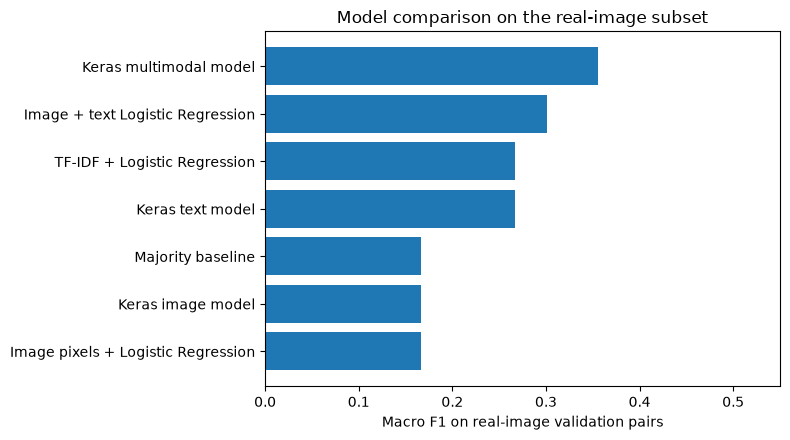

In [9]:
plot_data = comparison.sort_values("real_image_macro_f1")
plt.figure(figsize=(8, 4.5))
plt.barh(plot_data["model"], plot_data["real_image_macro_f1"])
plt.xlabel("Macro F1 on real-image validation pairs")
plt.xlim(0, 0.55)
plt.title("Model comparison on the real-image subset")
plt.tight_layout()
plt.show()

The complete TensorFlow run produced the following Keras multimodal result:

- **0.5000 accuracy and 0.4898 macro F1** on all 60 validation pairs;
- **0.3667 accuracy and 0.3556 macro F1** on the 30 real-image pairs.

The simple image-and-text Logistic Regression baseline reaches **0.3333 accuracy and 0.3015 macro F1** on the real-image pairs. The comparison is based on a small validation set, so it should be treated as a course experiment rather than a general conclusion.


## 7. What the multimodal model gets wrong

The next confusion matrix uses only the real-image subset. This is the part of the evaluation that is not affected by the visually similar generated drawings.

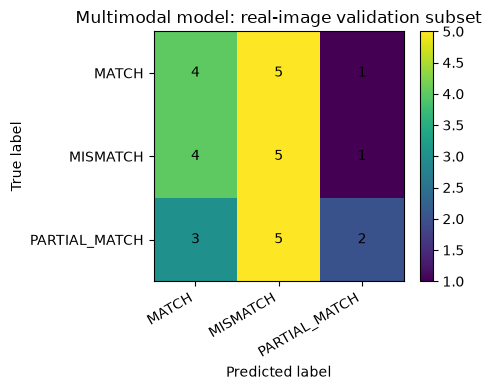

In [10]:
labels = ["MATCH", "MISMATCH", "PARTIAL_MATCH"]
real_predictions = predictions[predictions.source.eq("wikimedia")].copy()
matrix = confusion_matrix(
    real_predictions.true_label,
    real_predictions.predicted_label,
    labels=labels,
)

fig, ax = plt.subplots(figsize=(5, 4))
image = ax.imshow(matrix)
ax.set_xticks(range(3), labels=labels, rotation=30, ha="right")
ax.set_yticks(range(3), labels=labels)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Multimodal model: real-image validation subset")
for i in range(3):
    for j in range(3):
        ax.text(j, i, matrix[i, j], ha="center", va="center")
plt.colorbar(image, ax=ax)
plt.tight_layout()
plt.show()

In [11]:
print(classification_report(
    real_predictions.true_label,
    real_predictions.predicted_label,
    labels=labels,
    digits=3,
    zero_division=0,
))

               precision    recall  f1-score   support

        MATCH      0.364     0.400     0.381        10
     MISMATCH      0.333     0.500     0.400        10
PARTIAL_MATCH      0.500     0.200     0.286        10

     accuracy                          0.367        30
    macro avg      0.399     0.367     0.356        30
 weighted avg      0.399     0.367     0.356        30



`PARTIAL_MATCH` is the strongest class in this subset. `MATCH` is difficult because the model sometimes predicts `MISMATCH` even when the text names the correct part.

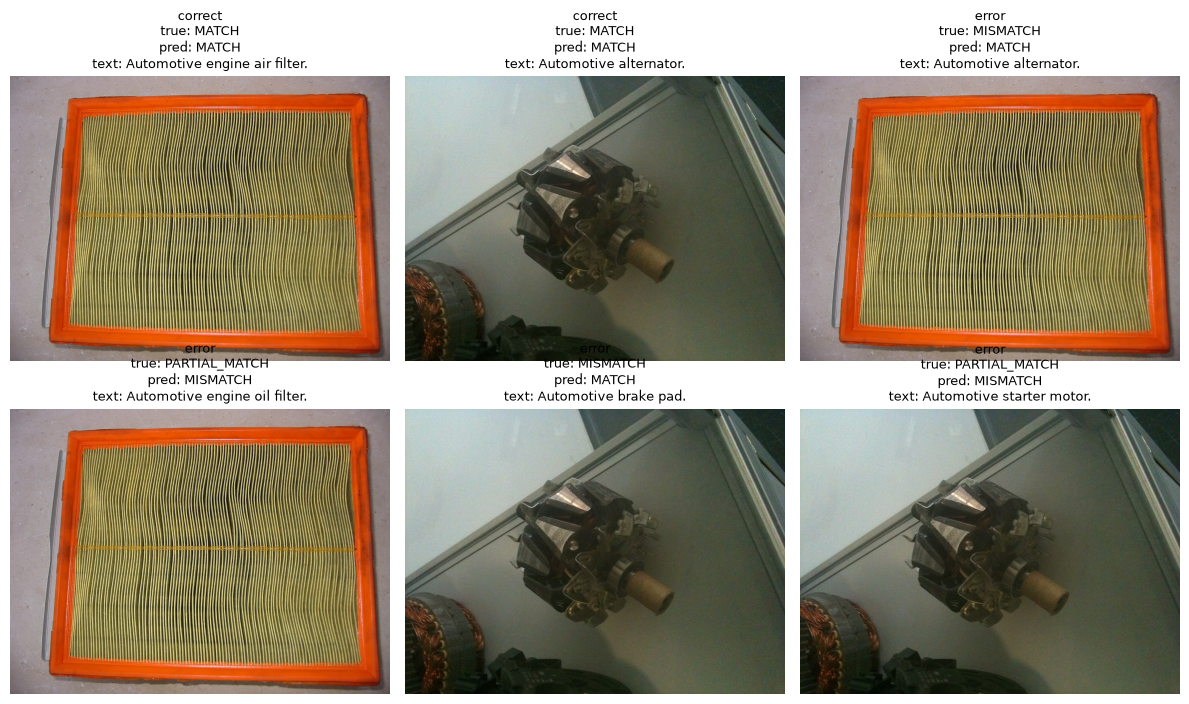

In [12]:
examples = pd.concat([
    real_predictions[real_predictions.is_correct.eq(True)].head(2),
    real_predictions[real_predictions.is_correct.eq(False)].head(4),
], ignore_index=True)

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, row in zip(axes.flat, examples.itertuples(index=False)):
    with Image.open(ROOT / row.image_path) as image:
        ax.imshow(image.convert("RGB"))
    status = "correct" if row.is_correct else "error"
    ax.set_title(
        f"{status}\ntrue: {row.true_label}\npred: {row.predicted_label}\ntext: {row.description}",
        fontsize=9,
    )
    ax.axis("off")
plt.tight_layout()
plt.show()

## 8. Results by part category

There are only six validation rows per category, so these values are noisy. I use them to find weak areas, not to claim a stable ranking between categories.

In [13]:
category_results = pd.read_csv(ROOT / "results/multimodal_per_category.csv")
category_results.round(3)

,part_category,samples,accuracy,macro_f1
0,air_filter,6,0.500,0.400
1,alternator,6,0.500,0.400
2,brake_disc,6,0.500,0.444
3,brake_pad,6,0.500,0.400
4,coil_spring,6,0.333,0.300
5,headlight,6,0.500,0.444
6,oil_filter,6,0.667,0.556
7,shock_absorber,6,0.667,0.556
8,starter,6,0.500,0.444
9,taillight,6,0.333,0.356


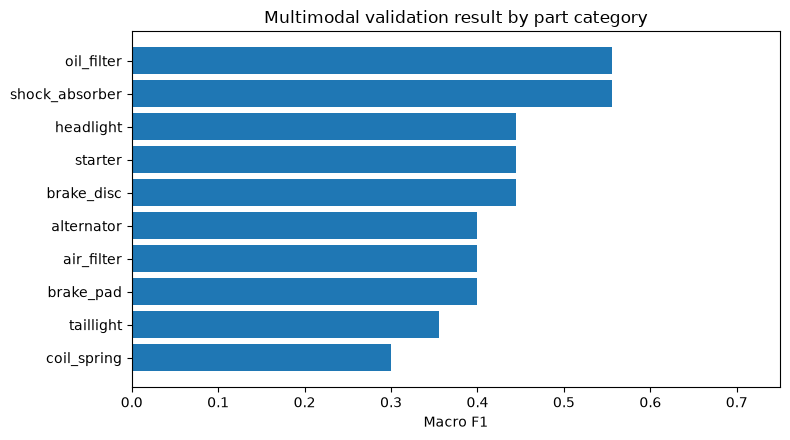

In [14]:
category_plot = category_results.sort_values("macro_f1")
plt.figure(figsize=(8, 4.5))
plt.barh(category_plot["part_category"], category_plot["macro_f1"])
plt.xlabel("Macro F1")
plt.xlim(0, 0.75)
plt.title("Multimodal validation result by part category")
plt.tight_layout()
plt.show()

## 9. Previous research

Visual-semantic embedding methods such as VSE++ learn a shared space for images and text [1]. VisualBERT combines visual regions and language in a transformer model [2]. CLIP learns image-text representations from a much larger dataset [3]. ResNet is a standard reference for deep image models [4].

My project is much smaller. I do not compare the published scores directly because the datasets and tasks are different. I use these papers only as motivation for combining visual and text information.

## 10. Conclusion

The small Keras multimodal model performed better than the unimodal models and the simple image-and-text Logistic Regression baseline on this validation split. It reached 0.5000 accuracy and 0.4898 macro F1 on all 60 validation pairs. On the real-image subset it reached 0.3667 accuracy and 0.3556 macro F1, compared with 0.3333 accuracy and 0.3015 macro F1 for the simple multimodal baseline.

The result suggests that the learned neural combination helped on this experiment, but it is not a final answer. The real-image subset has only 30 pairs, all validation descriptions are also present in training, and the generated drawings contain similar train-validation examples. A better next experiment would collect more independent real images and more varied text, then evaluate once on the locked test split after the model is fixed.

## Limitations

- small dataset;
- one real validation image per category;
- all validation descriptions also occur in training;
- image-only prediction is structurally limited because every image has all three relation labels;
- simple image branch without a pretrained backbone;
- generated images are too similar in some cases;
- validation was used for model comparison;
- one fixed random seed was used;
- the test split was not used.

## Reproduction

```powershell
python -m pip install -r requirements.txt
python -m src.audit
python -m pytest -q
python -m src.train
python -m jupyter notebook project.ipynb
```

`python -m src.train` regenerates the comparison table, all validation predictions, the multimodal error-analysis files, the training histories, the model summaries, and `run_info.json`.

The saved predictions, metrics and training histories in this checkpoint were generated by running `python -m src.train` from the current project files. The training split was used for fitting, the validation split was used for model comparison, and the locked test split was not opened.

## References

1. Faghri et al., **VSE++: Improving Visual-Semantic Embeddings with Hard Negatives**, BMVC 2018. https://arxiv.org/abs/1707.05612
2. Li et al., **VisualBERT: A Simple and Performant Baseline for Vision and Language**, 2019. https://arxiv.org/abs/1908.03557
3. Radford et al., **Learning Transferable Visual Models From Natural Language Supervision**, ICML 2021. https://arxiv.org/abs/2103.00020
4. He et al., **Deep Residual Learning for Image Recognition**, CVPR 2016. https://arxiv.org/abs/1512.03385